# 08 · Balanceo de clases

**Proyecto Final — Machine Learning y Deep Learning**

Las clases de nuestro problema están **desbalanceadas**: hay más reservas que **no** se cancelan que canceladas. Este notebook explica qué implica eso, qué técnicas existen para tratarlo y qué **efecto real** tienen.

> 📖 Términos en `docs/glosario.md`. Implementación en `src/balancing.py`.

## 1. ¿Qué es el desbalance de clases y por qué importa?

Un conjunto está **desbalanceado** cuando una clase aparece mucho más que la otra. Eso causa dos problemas:

- **La *accuracy* engaña:** si el 63 % de las reservas no se cancelan, un modelo que dijera siempre "no cancela" acertaría el 63 %… sin haber aprendido nada.
- **El modelo tiende a descuidar la clase minoritaria:** con pocos ejemplos de cancelación, puede aprender a no detectarlas bien (bajo *recall*).

Ya lo mitigamos con dos decisiones del proyecto: partición **estratificada** (mantener la proporción al dividir) y usar **ROC-AUC** como métrica principal (no se deja engañar por la clase mayoritaria). Aquí vamos más allá con técnicas específicas de balanceo.

## 2. El desbalance en nuestros datos

Veámoslo. Es un desbalance **moderado** (~37 % de cancelaciones), no extremo como en fraude o enfermedades raras, que pueden ser <1 %.

Proporción de clases (train):
is_canceled
0    0.629
1    0.371
Name: proportion, dtype: float64


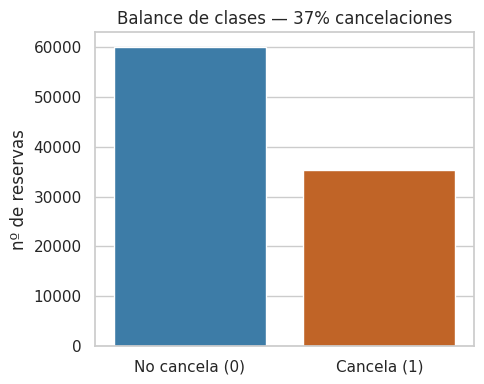

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from ml_hotel_cancellations.ml.data_loader import load_and_prepare

X_train, X_test, y_train, y_test = load_and_prepare()
conteo = y_train.value_counts().sort_index()
prop = y_train.value_counts(normalize=True).sort_index()
print('Proporción de clases (train):'); print(prop.round(3))
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=['No cancela (0)', 'Cancela (1)'], y=conteo.values,
            palette=['#2c7fb8', '#d95f0e'], ax=ax)
ax.set_title(f'Balance de clases — {prop.iloc[1]:.0%} cancelaciones')
ax.set_ylabel('nº de reservas')
plt.tight_layout(); plt.show()

## 3. Técnicas para tratar el desbalance

Hay dos familias principales:

### a) Reponderar (*cost-sensitive*)
- **`class_weight='balanced'`** (regresión logística, árbol, Random Forest): da **más peso** a los errores en la clase minoritaria, así el modelo "presta más atención" a las cancelaciones. En XGBoost el equivalente es **`scale_pos_weight`**.
- No cambia los datos, solo **cómo se penalizan** los errores al entrenar.

### b) Remuestrear (cambiar los datos de entrenamiento)
- **SMOTE** (*Synthetic Minority Over-sampling*): **crea ejemplos sintéticos** de la clase minoritaria interpolando entre vecinos cercanos, hasta equilibrar las clases. Se aplica **solo al entrenamiento** (nunca al test, o las métricas mentirían).
- **Undersampling**: al revés, **elimina** ejemplos de la mayoritaria. Más simple, pero descarta información.

Comparamos *baseline* (sin balanceo) vs *class_weight* vs *SMOTE*.

## 4. Comparación práctica

Entrenamos los modelos clásicos con cada estrategia (reutilizando `src/balancing.py`) y medimos en test. Para **aislar el efecto del balanceo**, se usan los hiperparámetros base. *(Entrena 12 modelos: tarda un par de minutos.)*

In [2]:
from ml_hotel_cancellations.ml.balancing import compare

tabla = compare(X_train, X_test, y_train, y_test)
metr = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
tabla.style.background_gradient(cmap='Greens', subset=['recall']).format(
    {c: '{:.3f}' for c in metr})

,modelo,estrategia,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,baseline,0.825,0.805,0.696,0.746,0.907
1,Decision Tree,baseline,0.854,0.826,0.768,0.796,0.934
2,Random Forest,baseline,0.861,0.887,0.717,0.793,0.943
3,XGBoost,baseline,0.883,0.857,0.819,0.838,0.955
4,Logistic Regression,class_weight,0.822,0.735,0.813,0.772,0.908
5,Decision Tree,class_weight,0.836,0.732,0.878,0.799,0.929
6,Random Forest,class_weight,0.868,0.813,0.837,0.825,0.944
7,XGBoost,class_weight,0.877,0.806,0.878,0.841,0.955
8,Logistic Regression,SMOTE,0.822,0.735,0.812,0.772,0.907
9,Decision Tree,SMOTE,0.847,0.764,0.849,0.804,0.932


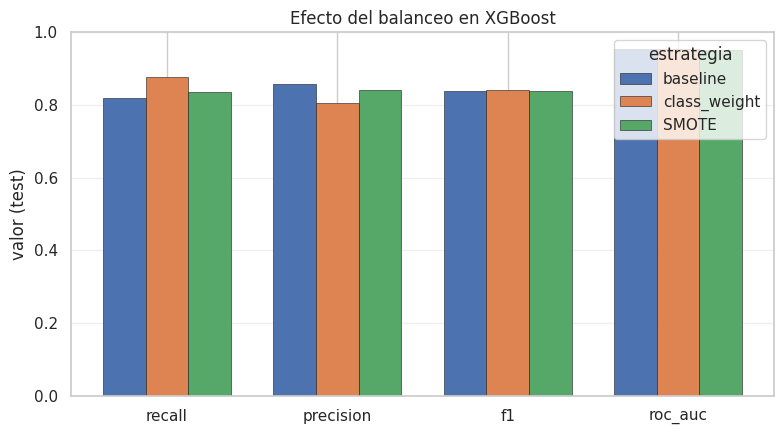

In [3]:
# Efecto del balanceo en XGBoost: sube recall, baja precisión, ROC-AUC casi igual
sub = tabla[tabla['modelo'] == 'XGBoost'].set_index('estrategia')
metr = ['recall', 'precision', 'f1', 'roc_auc']
fig, ax = plt.subplots(figsize=(8, 4.5)); x = np.arange(len(metr)); w = 0.25
for i, est in enumerate(['baseline', 'class_weight', 'SMOTE']):
    ax.bar(x + (i - 1) * w, sub.loc[est, metr].values, w, label=est,
           edgecolor='k', linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(metr); ax.set_ylim(0, 1)
ax.set_ylabel('valor (test)'); ax.set_title('Efecto del balanceo en XGBoost')
ax.legend(title='estrategia'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Conclusión: qué logran y cuándo usarlas

- El balanceo **sube el recall** (se detectan más cancelaciones) a costa de **bajar la precisión** (más falsas alarmas).
- El **ROC-AUC apenas cambia**: balancear no mejora la capacidad del modelo de *ordenar* por riesgo; solo desplaza el **umbral** efectivo hacia detectar más positivos.
- **Cuándo usarlas:** cuando el coste de **no detectar** una cancelación supera al de una falsa alarma (p. ej. para activar *overbooking*). Si lo que importa es ordenar bien por riesgo (nuestro caso, ROC-AUC), **no hace falta**: por eso el pipeline principal no balancea y, si hubiera que priorizar recall, bastaría con **mover el umbral** de decisión.

En problemas con desbalance **extremo** (<5 %), estas técnicas —sobre todo SMOTE— son mucho más decisivas que en este caso moderado.